# Hebrew Acronym Disambiguation: Experimental Study

How does Hebrew acronym disambiguation differ between free generation and selection from a candidate inventory? This notebook analyzes separately identified, saved test runs, retaining incomplete responses and the complete test denominators. It compares trained DictaBERT selection with the collected LLM task pairs; model size, architecture, training and service differences are not isolated causal factors.

**Default execution is offline saved-result analysis.** No API account, model weights or private artifact directory is required. The tables and figures below are saved in this notebook. Install the package as described in the [README](../README.md#install-and-check), then run cells in order. Input checks reject missing or mismatched evidence. The optional development appendix is disabled by default and is not part of the test findings.

The collection was performed in separate sessions, not as one uninterrupted notebook run. Gemini has a completed development pilot but no test run in this release. Human semantic review is pending; automatic scores are not human judgments.

DictaLM Ollama and LoRA code is available, but no identified, verified DictaLM result is included in this evidence bundle.

In [1]:
from pathlib import Path
from uuid import uuid4
from IPython.display import HTML, display
from hebrew_acronyms import experimental_study as study
from hebrew_acronyms.paper_export import export_paper
from hebrew_acronyms.saved_study_comparison import display_saved_comparison

ROOT = Path.cwd().resolve()
ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
RUN_DEVELOPMENT_APPENDIX = globals().get("RUN_DEVELOPMENT_APPENDIX", False)
settings = dict(
    mode="preview", run_kind="validation", run_id=str(uuid4()), root=ROOT,
    train_path=ROOT / "data/study_v1/encoder_inputs/train.csv",
    input_path=ROOT / "data/study_v1/encoder_inputs/dev.csv", expected_dev_items=62,
    validation_items=3, device="cpu", checkpoint=None, snapshot_path=None,
    checkpoint_format="manifest", checkpoint_sha256=None, checkpoint_attestation=None,
    enable_encoder=False, saved_encoder=None, saved_encoder_run_id=None,
    enable_qwen=False, qwen_model="qwen2.5:7b", ollama_url="http://localhost:11434",
    qwen_options={}, enable_gemini=False, gemini_model="gemini-3.8-flash",
    gemini_generation_config={"thinkingConfig": {"thinkingLevel": "low"}},
    request_timeout=120, output_root=ROOT / "experiments/runs",
    saved_run=None, saved_run_id=None,
    paper_source_run_id=None,  # Set the exact selected full-dev run ID to enable paper export.
)


## 1. Data and evaluation protocol

The test cohort contains **381 items across 60 acronym types**: 253 Knesset sentences, 41 Wikipedia sentences and 87 AI-authored sentences. Runs saved on the earlier 395-item cohort are scored without the 14 items that share a Knesset document with training; their calls still count towards cost. Text provenance and labeling evidence are distinct; this is not a natural-text-only benchmark. See the [data inventory](../data/README.md) and [dataset card](../data/mined/DATASET_CARD.md) for construction and remaining provenance limitations.

Each LLM receives the same items in two tasks: **free generation**, with the sentence and target acronym but no candidates or gold answer; and **candidate selection**, with a fixed per-item candidate order and recorded label mapping. All 381 retained items remain in each task denominator, including technical failures. Trained DictaBERT performs selection only and uses the separately documented automatic target-position policy.

The technical pilot uses the first ten of **289 development items**, in both tasks. It establishes technical operation, not semantic accuracy. The historical encoder development cohort contains **62 items** and is separate from both the pilot and test cohorts. Its optional protocol appears in the appendix below; no invented preview contributes a research result.

The bundled `saved-results/` files retain full responses, failed attempts, settings and original identities. Loading validates session and run identities, test input snapshots, prompts, candidate orders, scoring code and baseline provenance before comparison. Collection revisions remain explicit. New requests are performed only through the separate [collection appendix](run_test_eval_colab.ipynb).

The 14-item exclusion was applied **after response collection**. The retained rows are field-for-field identical to the original 395-item split. The four excluded document titles overlap `data/study_v1/encoder_inputs/train.csv`; the remaining document titles do not overlap that qualified train/dev layer. This does not reconstruct the historical checkpoint training inputs or establish that all historical split files are overlap-free. Original 395-item manifests and journals remain unchanged.

In [2]:
SAVED_ARTIFACTS = ROOT / "saved-results"
RUN_SAVED_TEST_ANALYSIS = globals().get("RUN_SAVED_TEST_ANALYSIS", True)
if not RUN_SAVED_TEST_ANALYSIS:
    print("Saved test analysis explicitly disabled.")

if RUN_SAVED_TEST_ANALYSIS:
    from hebrew_acronyms.saved_test_comparison import compare_saved_tests, result_table
    import matplotlib.pyplot as plt
    from html import escape
    import json

    import hashlib
    inventory = json.loads((SAVED_ARTIFACTS / "files.json").read_text())
    for relative, evidence in inventory["files"].items():
        saved_file = SAVED_ARTIFACTS / relative
        if hashlib.sha256(saved_file.read_bytes()).hexdigest() != evidence["sha256"]:
            raise ValueError(f"Bundled evidence differs: {relative}")

    TEST_ARTIFACTS = SAVED_ARTIFACTS / "colab-runs"
    TEST_SESSIONS = [
        (TEST_ARTIFACTS / "evaluation-20261009-a319f9d/extracted",
         "8aa951a4ac96c126335f40ddc869cc7b6b6010cc94d7be1cc30925f09be9aac0"),
        (TEST_ARTIFACTS / "evaluation-gemini-retry-20261009-a319f9d/extracted",
         "837973fb8065fa7c6467d9370fb170ad58df757d3dadd33ae105910ecd245deb"),
        (TEST_ARTIFACTS / "evaluation-xai-qwen14-20261009-64f47b7/extracted",
         "f373731d81617852b35578fb78ab9d222598723f68e4907e9c5127392ebb5b64"),
        (TEST_ARTIFACTS / "evaluation-xai-qwen14-20261009-e9c8ef7/extracted",
         "2b185ec5d6baf1975629d82ec4608da353c376aaadebfbe7a483e80f5e6ee2f3"),
    ]
    TEST_RUN_IDS = {
        "xai": "885c4382ca904f0baca692ae9cc37ac9",
        "qwen": "cd1331b460364d4ebc341194c07dc1fe",
        "qwen14": "f23e084aace743e8a61a1a71dfbb33d4",
        "openai": "358e1fe65fa048c191eda08c078fd4cd",
        "anthropic": "3248737a597b435181227711caea89d0",
    }
    test_comparison = compare_saved_tests(TEST_SESSIONS, TEST_RUN_IDS, diagnostic_sources=[
        (TEST_ARTIFACTS / "evaluation-xai-qwen14-20261009-64f47b7/diagnostic/extracted",
         "e1436f143f73d846412d48f537cb8592afe1332de2879feba7f1572aae931d28",
         "6b3e9430e2b9f9b5f0fb298b87447b48f4eefa8fb7c659a1b7981602297deb77"),
    ])
    print("Validated test inputs:", test_comparison["test_source_sha256"])
    print("Distinct journalled attempts, including pilots:", test_comparison["unique_attempts"])

    from hebrew_acronyms.encoder_test_results import load_encoder_test
    encoder_test = load_encoder_test(
        SAVED_ARTIFACTS / "study-runs/dictabert-test-20261009-f49c3b5",
        ROOT / "data/splits/test_items.csv",
        expected_run_id="dictabert-test-20261009-f49c3b5",
        expected_identity="2d3a20743715252b1ed743458f8efe728743ec8502329cca517f5e746cd3a126",
        expected_predictions_sha256="51050d90e9067c50077f14cea660c3a4ceee761044f514665ad1066cd80187b8",
    )
    combined_test_metrics = test_comparison["metrics"] + [encoder_test["metric"]]
    # Verify post-collection exclusion against the original immutable row snapshot.
    import csv
    from hebrew_acronyms.test_cohort import DOCUMENT_OVERLAP_IDS
    original_manifest = TEST_SESSIONS[0][0] / "qwen/full-test/manifest.json"
    original_rows = json.loads(original_manifest.read_text())["identity"]["rows"]
    with (ROOT / "data/splits/test_items.csv").open(encoding="utf-8-sig") as handle:
        scored_rows = list(csv.DictReader(handle))
    assert len(original_rows) == 395 and len(scored_rows) == 381
    assert [r for r in original_rows if r["item_id"] not in DOCUMENT_OVERLAP_IDS] == scored_rows
    removed_rows = [r for r in original_rows if r["item_id"] in DOCUMENT_OVERLAP_IDS]
    assert {r["item_id"] for r in removed_rows} == DOCUMENT_OVERLAP_IDS
    title_sets = {}
    for split in ("train", "dev"):
        with (ROOT / f"data/study_v1/encoder_inputs/{split}.csv").open() as handle:
            title_sets[split] = {r["page_title"] for r in csv.DictReader(handle)} - {""}
    assert {r["page_title"] for r in removed_rows} <= title_sets["train"]
    assert all(not ({r["page_title"] for r in scored_rows} & titles) for titles in title_sets.values())
    print("Post-collection exclusion verified: 14 items / 4 documents; all 381 retained rows unchanged.")



Validated test inputs: ['6185f241bbaf681556c231080819a07b3233a30a04fd91b1149c685977a092a2']
Distinct journalled attempts, including pilots: 4122
Post-collection exclusion verified: 14 items / 4 documents; all 381 retained rows unchanged.


## 2. Systems and collection provenance

Model settings are shown as recorded, including output limits and thinking settings. Omitted provider defaults are not inferred. Run identifiers refer to the original collection, not to this analysis. Environment differences and model families prevent interpreting these results as an isolated causal effect of model size.

In [3]:
if RUN_SAVED_TEST_ANALYSIS:
    display(HTML(result_table(test_comparison["models"], {
        "system": "System", "model": "Requested model", "returned_models": "Returned model",
        "run_id": "Original test run ID", "calls": "API/local calls", "seconds": "Request time (s)",
    })))
    for model in test_comparison["models"]:
        details = {key: model[key] for key in (
            "collection_revision", "identity_sha256", "settings", "usage", "finish_reasons",
            "unverified", "manifest_path", "manifest_sha256")}
        details["manifest_path"] = str(Path(details["manifest_path"]).relative_to(ROOT))
        display(HTML("<details><summary>" + escape(model["system"]) +
                     " — settings and evidence</summary><pre style='white-space:pre-wrap;overflow-wrap:anywhere'>" +
                     escape(json.dumps(details, ensure_ascii=False, indent=2)) + "</pre></details>"))


System,Requested model,Returned model,Original test run ID,API/local calls,Request time (s)
anthropic,claude-haiku-5-5,"[""claude-haiku-5-5""]",3248737a597b435181227711caea89d0,790,1293.77367
openai,gpt-4.1-mini-2025-04-14,"[""gpt-4.1-mini-2025-04-14""]",358e1fe65fa048c191eda08c078fd4cd,790,560.722397
qwen,qwen2.5:7b,"[""qwen2.5:7b""]",cd1331b460364d4ebc341194c07dc1fe,790,299.802273
qwen14,qwen2.5:14b,"[""qwen2.5:14b""]",f23e084aace743e8a61a1a71dfbb33d4,790,1797.84083
xai,grok-4.7,"[""grok-4.7""]",885c4382ca904f0baca692ae9cc37ac9,795,6634.16782


## 3. Coverage and automatic scores

`historical_quote_normalized_gold_substring` is the existing string-based generation rule. `strict_candidate_label_v1` parses the selected label and compares its candidate with the stored gold expansion. Neither is a human semantic judgment. Each accuracy uses **all 381 scored items**; incomplete or absent responses do not disappear from the denominator. “Valid” retains its original task-specific definition and is not technical completion.
The trained DictaBERT arm performs selection only and uses `exact_candidate_match`. Its target marker follows the explicitly selected first-occurrence rule; the LLMs receive the acronym name in their prompts. No generation score is assigned to the encoder.

In [4]:
if RUN_SAVED_TEST_ANALYSIS:
    display(HTML(result_table(combined_test_metrics, {
        "system": "System", "task": "Task", "n_items": "All items",
        "n_completed": "Technically complete", "n_correct": "Automatically correct",
        "accuracy": "Automatic accuracy", "n_valid": "Valid under stored rule",
        "score": "Scoring rule", "status_counts": "All response statuses",
    })))


System,Task,All items,Technically complete,Automatically correct,Automatic accuracy,Valid under stored rule,Scoring rule,All response statuses
anthropic,generate,381,380,165,0.433070866,184,historical_quote_normalized_gold_substring,"{""response_received"": 380, ""incomplete_response"": 1}"
anthropic,select,381,379,339,0.88976378,379,strict_candidate_label_v1,"{""response_received"": 379, ""incomplete_response"": 2}"
openai,generate,381,380,129,0.338582677,139,historical_quote_normalized_gold_substring,"{""response_received"": 380, ""incomplete_response"": 1}"
openai,select,381,381,317,0.832020997,381,strict_candidate_label_v1,"{""response_received"": 381}"
qwen,generate,381,380,31,0.0813648294,31,historical_quote_normalized_gold_substring,"{""response_received"": 380, ""incomplete_response"": 1}"
qwen,select,381,381,223,0.585301837,381,strict_candidate_label_v1,"{""response_received"": 381}"
qwen14,generate,381,371,44,0.115485564,47,historical_quote_normalized_gold_substring,"{""response_received"": 371, ""incomplete_response"": 9, ""service_error"": 1}"
qwen14,select,381,381,266,0.69816273,374,strict_candidate_label_v1,"{""response_received"": 381}"
xai,generate,381,381,184,0.482939633,189,historical_quote_normalized_gold_substring,"{""response_received"": 381}"
xai,select,381,381,351,0.921259843,380,strict_candidate_label_v1,"{""response_received"": 381}"


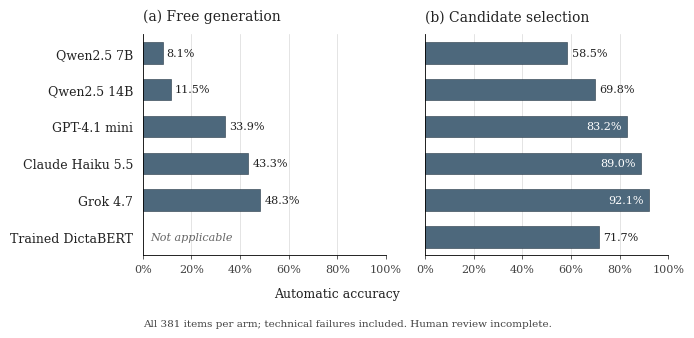

In [5]:
if RUN_SAVED_TEST_ANALYSIS:
    from matplotlib.ticker import MultipleLocator, PercentFormatter

    system_order = [name for name in ("qwen", "qwen14", "dictalm", "openai", "anthropic", "xai", "gemini") if name in TEST_RUN_IDS]
    system_order += ["dictabert"]
    # Short display names; exact model identities are retained in Section 2.
    model_labels = {"qwen": "Qwen2.5 7B", "qwen14": "Qwen2.5 14B", "dictalm": "DictaLM",
                    "openai": "GPT-4.1 mini", "anthropic": "Claude Haiku 5.5", "xai": "Grok 4.7",
                    "gemini": "Gemini", "dictabert": "Trained DictaBERT"}
    with plt.rc_context({"font.family": "serif", "font.serif": ["DejaVu Serif"], "font.size": 9,
                         "axes.titlesize": 10, "axes.labelsize": 9, "axes.linewidth": 0.6,
                         "axes.spines.top": False, "axes.spines.right": False,
                         "figure.facecolor": "white", "axes.facecolor": "white",
                         "text.color": "#222222", "axes.labelcolor": "#222222",
                         "xtick.color": "#444444", "ytick.color": "#222222",
                         "pdf.fonttype": 42, "svg.fonttype": "none"}):
        fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.45), sharex=True, sharey=True)
        fig.subplots_adjust(left=0.23, right=0.96, top=0.87, bottom=0.23, wspace=0.16)
        for ax, task, title in zip(axes, ("generate", "select"),
                                   ("(a) Free generation", "(b) Candidate selection")):
            groups = {m["system"]: m for m in combined_test_metrics if m["task"] == task}
            positions = [i for i, name in enumerate(system_order) if name in groups]
            values = [groups[system_order[i]]["accuracy"] for i in positions]
            bars = ax.barh(positions, values, color="#4D687C", edgecolor="#263746",
                           linewidth=0.4, height=0.58)
            for bar, value in zip(bars, values):
                inside = value >= 0.80
                ax.annotate(f"{value:.1%}", (value, bar.get_y() + bar.get_height() / 2),
                            xytext=(-4 if inside else 3, 0), textcoords="offset points",
                            ha="right" if inside else "left", va="center", fontsize=8,
                            color="white" if inside else "#222222")
            for i, name in enumerate(system_order):
                if name not in groups:
                    ax.text(0.03, i, "Not applicable" if name == "dictabert" else "Not measured",
                            va="center", fontsize=8, fontstyle="italic", color="#666666")
            ax.set_xlim(0, 1)
            ax.set_ylim(len(system_order) - 0.5, -0.5)
            ax.set_yticks(range(len(system_order)), [model_labels[name] for name in system_order])
            ax.set_title(title, loc="left", pad=10)
            ax.xaxis.set_major_locator(MultipleLocator(0.2))
            ax.xaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
            ax.tick_params(axis="x", labelsize=8, length=3, width=0.6)
            ax.tick_params(axis="y", length=0, pad=7)
            ax.grid(axis="x", color="#D9D9D9", linewidth=0.5)
            ax.set_axisbelow(True)
        fig.supxlabel("Automatic accuracy", fontsize=9, y=0.10)
        fig.text(0.23, 0.025,
                 f"All {test_comparison['n_scored_items']} items per arm; technical failures included. Human review incomplete.",
                 fontsize=7.5, color="#444444")
        plt.show()


## 4. Baselines and incomplete responses

The four saved candidate-selection baselines use the same test input. Uniform random is an analytical expectation, not a sampled run; oracle assumes the gold answer can be selected. The saved baseline summary uses four decimal places. These are not generation systems.

All incomplete model responses are retained below with their original run and item identifiers. Their full raw content remains in the journals; the table shows a bounded preview. No selective completion or replacement has been performed.

In [6]:
if RUN_SAVED_TEST_ANALYSIS:
    baseline_values = test_comparison["baselines"]["summary"]
    baseline_rows = [{"baseline": name, "accuracy": baseline_values[name], "n_items": baseline_values["n_items"]}
                     for name in ("random", "most_frequent", "most_mined", "oracle")]
    display(HTML(result_table(baseline_rows, {"baseline": "Selection baseline", "accuracy": "Saved accuracy", "n_items": "All items"})))
    print("Baseline source:", Path(test_comparison["baseline_path"]).relative_to(ROOT))
    failure_rows = [r | {"response_preview": r["response"][:160]} for r in test_comparison["failures"]]
    display(HTML(result_table(failure_rows, {"system": "System", "task": "Task", "item_id": "Item",
        "status": "Status", "finish_reason": "Finish reason", "attempts": "Attempts",
        "response_preview": "Response preview", "run_id": "Original run ID"})))


Selection baseline,Saved accuracy,All items
random,0.2351,381
most_frequent,0.3701,381
most_mined,0.4803,381
oracle,1,381


Baseline source: saved-results/colab-runs/evaluation-20261009-a319f9d/extracted/baselines/baselines.json


System,Task,Item,Status,Finish reason,Attempts,Response preview,Original run ID
anthropic,select,kn3-0059,incomplete_response,max_tokens,1,,3248737a597b435181227711caea89d0
anthropic,select,kn4-0409,incomplete_response,max_tokens,1,,3248737a597b435181227711caea89d0
anthropic,generate,kn4-0551,incomplete_response,max_tokens,1,לא ניתן לקבוע בוודאות מהמשפט לבד. ייתכן שמדובר,3248737a597b435181227711caea89d0
openai,generate,kn-0027,incomplete_response,length,1,"י״ח = י״ח (יח) = י""ח = י""ח (יח) = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח = י""ח =",358e1fe65fa048c191eda08c078fd4cd
qwen,generate,kn4-0486,incomplete_response,length,1,"אג""מ מייצגת אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ, שORTH אג""מ",cd1331b460364d4ebc341194c07dc1fe
qwen14,generate,kn3-0082,incomplete_response,length,1,"ע""א פירושו ""คณะกรรมה"" או ""คณะกรรมהAccessory""ependent on the context, but in this case, it likely refers to ""คณะกรรมה"" which stands for ""คณะกรรมהAccessory"" which",f23e084aace743e8a61a1a71dfbb33d4
qwen14,generate,kn4-0014,incomplete_response,length,1,"ח""ן פירושו חילNavItem 1NavItem 2NavItem 3NavItem 4NavItem 5NavItem 6NavItem 7NavItem 8NavItem 9NavItem 10NavItem 11NavItem 12NavItem 13NavItem 14NavItem 15NavIt",f23e084aace743e8a61a1a71dfbb33d4
qwen14,generate,kn4-0024,incomplete_response,length,1,"ראשי התיבות ""יו״ד"" פירושם ""ראשי democrats"" או ""ראשי демократов"" בדיאלקטים אחרים, אך בהקשר זה פירושו הוא ""יושב miejsce"" או ""יושבое место"" בדיאלקטים אחרים, המתייח",f23e084aace743e8a61a1a71dfbb33d4
qwen14,generate,kn4-0027,service_error,not reported,1,,f23e084aace743e8a61a1a71dfbb33d4
qwen14,generate,kn4-0048,incomplete_response,length,1,"חamberה""י"" הוא ראשי תיבות של ""חamberהיאן"" או ""חamberהיאנית"" שבדそのままן היא ""חamberהיאן"" או ""חamberהיאנית"" בעברית היא ""חamberהיאנית"" או ""חamberהיאן"" בהתאם ל Kontek",f23e084aace743e8a61a1a71dfbb33d4


## 5. Pilots and cumulative expenditure

Pilot records below are development observations, excluded from test scores. The additional Gemini pilot completed 20/20 logical responses in 22 calls, with two transient failed attempts recovered by the existing retry policy. All final responses reported the requested model and `STOP`; three attempts lacked complete usage, including one successful response. The original failed pilot is preserved separately.

The Gemini test is deferred from this release. Its pilot projected approximately 579 minutes for the full test; this is an extrapolation, not a completion guarantee. A completed pilot does not guarantee service availability throughout a longer run. No Gemini test score is available in this comparison.

Costs use recorded token usage and the collection tariffs, plus explicit allowances when usage is incomplete. They are not settled invoices. The original 4 ILS allowance is included once. Later sessions carry earlier expenditure; session totals are therefore **not added together**. The failed initial Qwen14/xAI pilots and the separately journalled xAI HTTP diagnostic are retained, including their uncertain-cost allowances. The corrected collection version has independently inspected pilots for both added systems. The conversion allowance is 4 ILS/USD.

In [7]:
if RUN_SAVED_TEST_ANALYSIS:
    display(HTML(result_table(test_comparison["pilots"], {
        "session": "Collection session", "system": "System", "run_id": "Pilot run ID",
        "completed": "Complete", "responses": "Planned responses", "calls": "Calls",
        "seconds": "Request time (s)", "token_cost_usd": "Token cost (USD)", "uncertain_usd": "Usage allowance (USD)",
    })))
    display(HTML(result_table(test_comparison["cost_sessions"], {
        "session": "Collection session", "prior_ils": "Carried prior (ILS)",
        "new_token_cost_ils": "New token cost (ILS)", "new_uncertain_ils": "New usage allowance (ILS)",
        "cumulative_ils": "Cumulative accounted (ILS)",
    })))
    display(HTML(result_table([test_comparison["cost"]], {
        "initial_prior_allocation_ils": "Original allowance (ILS)", "token_cost_ils": "All measured token costs (ILS)",
        "uncertain_attempt_allowances_ils": "All uncertain attempt allowances (ILS)",
        "total_accounted_ils": "Accounted total (ILS)",
    })))


Collection session,System,Pilot run ID,Complete,Planned responses,Calls,Request time (s),Token cost (USD),Usage allowance (USD)
evaluation-20261009-a319f9d,anthropic,a2ed93ec08da454cb73851ccf4929092,20,20,20,32.2454072,0.0019857,0
evaluation-20261009-a319f9d,gemini,fd458353b8be4d8ba62053eef017c5b4,3,20,5,105.697936,0.00173775,0.011154
evaluation-20261009-a319f9d,openai,bc97b54c326c4a919f1c683410d8106d,20,20,20,19.7813363,0.0009264,0
evaluation-20261009-a319f9d,qwen,30f948213a7f4d24ba1912b4b800a5be,20,20,20,117.225951,0,0
evaluation-gemini-retry-20261009-a319f9d,gemini,3138d8f90c464d548526a5d9b44f0c9d,20,20,22,880.009829,0.006327,0.016731
evaluation-xai-qwen14-20261009-64f47b7,qwen14,a7b389d6912849c986abed4ea754b2b1,19,20,20,159.56536,0,0
evaluation-xai-qwen14-20261009-64f47b7,xai,acd75ec22c764c17b4950c534238598f,0,20,20,12.6178771,0,0.21552
evaluation-xai-qwen14-20261009-e9c8ef7,qwen14,ab6e9bdd23bc4fcf8f76950fd6e470a0,20,20,20,31.7718131,0,0
evaluation-xai-qwen14-20261009-e9c8ef7,xai,cd873946d1754761988147a5d993ffc9,20,20,20,126.84919,0.103936,0


Collection session,Carried prior (ILS),New token cost (ILS),New usage allowance (ILS),Cumulative accounted (ILS)
evaluation-20261009-a319f9d,4,0.4702514,0.044616,4.5148674
evaluation-gemini-retry-20261009-a319f9d,4.5148674,0.025308,0.066924,4.6070994
evaluation-xai-qwen14-20261009-64f47b7,4.6070994,0,0.86208,5.4691794
evaluation-xai-qwen14-20261009-64f47b7/xai-http-diagnostic,5.4691794,0,0.043104,5.5122834
evaluation-xai-qwen14-20261009-e9c8ef7,5.5122834,15.93352,0.21552,21.6613234


Original allowance (ILS),All measured token costs (ILS),All uncertain attempt allowances (ILS),Accounted total (ILS)
4,16.4290794,1.232244,21.6613234


## 6. Interpretation limits

The comparison preserves the collected systems, prompts, candidate orders, labels, scoring rules, and full denominators. The original five truncated test responses remain failures. Qwen14 additionally retains nine truncated generation responses and one HTTP failure; none is selectively replaced. The test set mixes Knesset, Wikipedia, and authored examples; automatic label agreement should not be interpreted as natural-text-only generalization or human semantic accuracy. Known label and inventory limitations are not corrected by this analysis.

Human review remains incomplete. The new trained-encoder test run uses explicitly recorded, automatically derived first-occurrence target spans; these are not human-validated annotations. The historical training-input, library and seed provenance remains incomplete despite the verified checkpoint load and new inference. Software validation of this loader establishes comparison and accounting checks; it is not additional experimental evidence. The analysis revision is recorded separately from the original collection revision.

## 7. Trained encoder provenance and collection status

The approved checkpoint was loaded strictly and evaluated on all 395 then-current test items after a three-item technical validation; it is scored on the 381 items without document overlap. This is fresh inference without retraining, recorded separately from the LLM sessions. The 395 selected candidates agree individually with the historical CSV; this reproduces its choices but does not recover the original execution provenance. First-occurrence marker placement is an explicit automatic policy, not a human annotation.

In [8]:
if RUN_SAVED_TEST_ANALYSIS:
    encoder_identity = encoder_test["manifest"]["identity"]
    display(HTML(result_table([{
        "run": encoder_test["manifest"]["run_id"],
        "revision": encoder_identity["code_revision"],
        "weights": encoder_identity["weights_sha256"],
        "target_policy": encoder_identity["target_policies"],
        "configuration": encoder_test["reconstruction"]["architecture"],
        "remaining_provenance_gaps": encoder_test["reconstruction"]["unknowns"],
    }], {"run": "Encoder test run", "revision": "Inference revision", "weights": "Checkpoint SHA-256",
         "target_policy": "Target policy", "configuration": "Architecture and encoding",
         "remaining_provenance_gaps": "Unresolved historical training provenance"})))
    status_rows = [{"system": "DictaBERT", "test": f"{encoder_test['metric']['n_items']} scored items, selection; generation not applicable"}]
    for name, label in (("qwen", "Qwen2.5 7B"), ("qwen14", "Qwen2.5 14B"), ("dictalm", "DictaLM"),
                        ("openai", "OpenAI"), ("anthropic", "Claude"),
                        ("xai", "xAI"), ("gemini", "Gemini")):
        groups = [r for r in test_comparison["metrics"] if r["system"] == name]
        pilots = [r for r in test_comparison["pilots"] if r["system"] == name]
        if groups:
            status = "; ".join(f"{r['task']}: {r['n_completed']}/{r['n_items']} technically complete" for r in groups)
        elif pilots:
            status = f"Latest pilot: {pilots[-1]['completed']}/20; no saved test run"
        else:
            status = "No collected pilot or test in this bundle"
        status_rows.append({"system": label, "test": status})
    display(HTML(result_table(status_rows, {"system": "System", "test": "Recorded collection status"})))


Encoder test run,Inference revision,Checkpoint SHA-256,Target policy,Architecture and encoding,Unresolved historical training provenance
dictabert-test-20261009-f49c3b5,f49c3b50f95b4ec022b35ba262a96a3a72cc937b,23bbff0324a7ce4d9d4a24a9ebfb87a4f6ac296bf1f1ce1bd25126c09260267f,"{""legacy_first_occurrence_not_human_validated"": 395}","{""config"": {""hidden_size"": 768, ""intermediate_size"": 3072, ""max_position_embeddings"": 512, ""model_type"": ""bert"", ""num_attention_heads"": 12, ""num_hidden_layers"": 12, ""type_vocab_size"": 2, ""vocab_size"": 128000}, ""context_truncation"": ""outside-in, retaining target and candidate"", ""dropout"": 0.1, ""head"": ""Linear(768, 1)"", ""max_len"": 256, ""model_id"": ""dicta-il/dictabert"", ""pair_layout"": ""[CLS] marked_context [SEP] candidate [SEP]"", ""pooling"": ""cls""}","[""original training library versions"", ""original resolved base-model/tokenizer revision and tokenizer hash"", ""exact training rows identity and selected epoch/loss"", ""actual training seed (filename seed43; reference notebook seed42)""]"


System,Recorded collection status
DictaBERT,"381 scored items, selection; generation not applicable"
Qwen2.5 7B,generate: 380/381 technically complete; select: 381/381 technically complete
Qwen2.5 14B,generate: 371/381 technically complete; select: 381/381 technically complete
DictaLM,No collected pilot or test in this bundle
OpenAI,generate: 380/381 technically complete; select: 381/381 technically complete
Claude,generate: 380/381 technically complete; select: 379/381 technically complete
xAI,generate: 381/381 technically complete; select: 381/381 technically complete
Gemini,Latest pilot: 20/20; no saved test run


## 8. Human semantic review coverage

Human judgments remain separate from the automatic scores in Section 3. The review input binds each answer to its original item, task, collection run and exact response text. Historical judgments are not assigned to changed answers. Only explicitly completed reviews with a matching saved snapshot contribute judgments below; drafts remain unreviewed for this analysis.

The queue includes every automatically nonpositive answer and a separate positive-review queue. Technical failures remain identified. A human-correct answer among automatic nonpositives is evidence of a false negative for that answer; a human-wrong answer among automatic positives is evidence of a false positive. Partial and undecidable judgments are reported separately. Incomplete queue coverage cannot rule out further disagreements. No gold labels or prompts are revised from test review.

The original review bundles contain a 20-answer calibration queue. The new compact route interleaves 16 generation-negative groups, four generation-positive groups and two selection groups, with a ten-minute calibration limit regardless of completion. It is not a representative evaluation sample. Any time projection below uses recorded wall-clock times, includes breaks, and is only a planning estimate.

The identified compact review uses the same 381-item cohort and original answer bindings. Exact duplicates within one item/context/task can share one decision while retaining all source occurrences. Priority is diagnostic, based on variants and similarity, interleaved across systems and with controls; it is not random sampling. No historical judgments are transferred. The first saved judgment starts a 60-minute wall-clock limit; optional notes and `unsure` are supported. Technical failures stay separate. “Unresolved” below includes unreviewed responses and reviewed `unsure` responses. Per-system decision counts can overlap and must not be added.

In [9]:
if RUN_SAVED_TEST_ANALYSIS:
    from hebrew_acronyms.test_review_export import review_coverage
    REVIEW_DIRECTORIES = [
        "human-review-xai-test-20261009",
        "human-review-test-20261009", "human-review-dictabert-test-20261009",
        "human-review-qwen14-test-20261009",
    ]
    coverage_bundles = []
    for directory in REVIEW_DIRECTORIES:
        review_root = SAVED_ARTIFACTS / directory
        if (review_root / "review-data.json").exists():
            coverage_bundles.append((directory, review_coverage(
                review_root / "review-data.json", review_root / "annotations.json")))
        else:
            print("Review input missing:", directory)
    if coverage_bundles:
        coverage_rows = [row for _, coverage in coverage_bundles for row in coverage["rows"]]
        review_runs = [(r["run_id"], r["task"]) for r in coverage_rows]
        if len(review_runs) != len(set(review_runs)):
            raise ValueError("Overlapping human-review cohorts would duplicate coverage")
        human_model_names = {m["system"]: m["model"] for m in test_comparison["models"]}
        human_model_names["dictabert"] = "Trained DictaBERT"
        human_rows = [r | {
            "model": human_model_names.get(r["system"].rsplit("_", 1)[0], r["system"]),
            "nonpositive_coverage": f"{r['automatic_nonpositive_reviewed']}/{r['automatic_nonpositive_total']}",
            "positive_coverage": f"{r['automatic_positive_reviewed']}/{r['automatic_positive_total']}",
        } for r in coverage_rows]
        display(HTML(result_table(human_rows, {
            "model": "Model", "task": "Task", "total": "Queued",
            "reviewed": "Reviewed", "not_reviewed": "Not reviewed",
            "human_undecidable": "Undecidable", "technical_failures": "Technical failures",
        })))
        display(HTML(result_table(human_rows, {
            "model": "Model", "task": "Task", "human_correct": "Human correct",
            "human_wrong": "Human wrong", "human_partial": "Partial",
            "human_undecidable": "Undecidable", "human_no_answer": "No answer",
        })))
        display(HTML(result_table(human_rows, {
            "model": "Model", "task": "Task",
            "nonpositive_coverage": "Nonpositives reviewed / all",
            "positive_coverage": "Positives reviewed / all",
            "automatic_nonpositive_human_correct": "Automatic nonpositive / human correct",
            "automatic_positive_human_wrong": "Automatic positive / human wrong",
        })))
        for directory, coverage in coverage_bundles:
            print(directory, "— judgment file included:", coverage["annotations_present"])
            print("Pace estimate:", coverage["pace"] or "Fewer than 20 completed timed reviews; no estimate.")
    else:
        print("Human-review input and judgments are not included in this bundle; coverage is not established.")

    identified_export = SAVED_ARTIFACTS / "human-review-381-20261010/review-export.json"
    if identified_export.exists():
        from hebrew_acronyms.test_review_export import identified_review_coverage
        identified_coverage = identified_review_coverage(identified_export, SAVED_ARTIFACTS, ROOT / "data/splits/test_items.csv")
        display(HTML(result_table(identified_coverage["rows"], {
            "system":"System", "task":"Task", "reviewed":"Reviewed", "total":"All responses",
            "decisions":"Decisions touching system", "positive_reviewed":"Positives reviewed",
            "positive_total":"All positives", "negative_reviewed":"Negatives reviewed",
            "negative_total":"All technical-complete negatives", "technical_failures":"Technical failures",
            "unsure":"Reviewed unsure", "unresolved":"All unresolved",
            "automatic_negative_human_fits":"Observed automatic false negatives",
            "automatic_positive_human_not_fits":"Observed automatic false positives",
        })))
        print("Distinct human decisions:", identified_coverage["decisions"],
              "Original responses covered:", identified_coverage["covered_answers"])
        print("Recorded manual window:", identified_coverage["manual_session"])
    else:
        print("Identified 381-item review: no exported human judgments in this release.")


Model,Task,Queued,Reviewed,Not reviewed,Undecidable,Technical failures
grok-4.7,generation,381,0,381,0,0
grok-4.7,selection,381,0,381,0,0
qwen2.5:7b,generation,381,0,381,0,1
gpt-4.1-mini-2025-04-14,generation,381,0,381,0,1
claude-haiku-5-5,generation,381,0,381,0,1
claude-haiku-5-5,selection,381,0,381,0,2
qwen2.5:7b,selection,381,0,381,0,0
gpt-4.1-mini-2025-04-14,selection,381,0,381,0,0
Trained DictaBERT,selection,381,0,381,0,0
qwen2.5:14b,generation,381,0,381,0,10


Model,Task,Human correct,Human wrong,Partial,Undecidable,No answer
grok-4.7,generation,0,0,0,0,0
grok-4.7,selection,0,0,0,0,0
qwen2.5:7b,generation,0,0,0,0,0
gpt-4.1-mini-2025-04-14,generation,0,0,0,0,0
claude-haiku-5-5,generation,0,0,0,0,0
claude-haiku-5-5,selection,0,0,0,0,0
qwen2.5:7b,selection,0,0,0,0,0
gpt-4.1-mini-2025-04-14,selection,0,0,0,0,0
Trained DictaBERT,selection,0,0,0,0,0
qwen2.5:14b,generation,0,0,0,0,0


Model,Task,Nonpositives reviewed / all,Positives reviewed / all,Automatic nonpositive / human correct,Automatic positive / human wrong
grok-4.7,generation,0/197,0/184,0,0
grok-4.7,selection,0/30,0/351,0,0
qwen2.5:7b,generation,0/350,0/31,0,0
gpt-4.1-mini-2025-04-14,generation,0/252,0/129,0,0
claude-haiku-5-5,generation,0/216,0/165,0,0
claude-haiku-5-5,selection,0/42,0/339,0,0
qwen2.5:7b,selection,0/158,0/223,0,0
gpt-4.1-mini-2025-04-14,selection,0/64,0/317,0,0
Trained DictaBERT,selection,0/108,0/273,0,0
qwen2.5:14b,generation,0/337,0/44,0,0


human-review-xai-test-20261009 — judgment file included: False
Pace estimate: Fewer than 20 completed timed reviews; no estimate.
human-review-test-20261009 — judgment file included: False
Pace estimate: Fewer than 20 completed timed reviews; no estimate.
human-review-dictabert-test-20261009 — judgment file included: False
Pace estimate: Fewer than 20 completed timed reviews; no estimate.
human-review-qwen14-test-20261009 — judgment file included: False
Pace estimate: Fewer than 20 completed timed reviews; no estimate.
Identified 381-item review: no exported human judgments in this release.


## Appendix A. Optional development workflow

This retained five-arm development workflow covers trained DictaBERT and the Qwen/Gemini task pairs on a separate 62-item cohort. It is **disabled by default**. Set `RUN_DEVELOPMENT_APPENDIX=True` in the setup cell only to inspect the invented `preview`, load an explicitly identified historical run with `reload`, or conduct a separately authorized development experiment with `run`. The preview is an engineering demonstration, not an experimental result.

Development LLM prompts use marked occurrences; they must not be pooled with the later test protocol. Collection, training and paper export remain explicit operations. The [training appendix](train_dictabert.ipynb) and [checkpoint documentation](../docs/checkpoints.md) record model-loading requirements and incomplete historical training provenance.

### A.1. Inputs

The qualified dev set contains 62 items. `validation` selects three and limits each enabled LLM to one request per task; `full_dev` uses all items. The saved cohort identifies the selected rows and the full dev input.

In [10]:
if RUN_DEVELOPMENT_APPENDIX:
    rows, cohort = study.read_study_inputs(settings)
    artifact = study.prepare_study(rows, cohort, settings)
    run = artifact["settings"]
    request_limit = 1 if run.get("run_kind") == "validation" else None
    print("Run:", artifact["run_id"], "Items:", len(rows))


### A.2. DictaBERT selection

The default manifest route compares original train/full-dev identities before inference. For the explicitly authorized complete Colab state dictionary, set `checkpoint_format="colab_state_dict"`, the checkpoint and local snapshot paths, its authorized `checkpoint_sha256`, and the supplied `checkpoint_attestation`. The separate adapter requires a full strict load and validates three items before continuing. Its reconstruction evidence records unknown training provenance without inventing an original manifest.


In [11]:
if RUN_DEVELOPMENT_APPENDIX:
    encoder_predictions = None
    if settings["mode"] == "run" and (run["enable_encoder"] or run["saved_encoder"]):
        if run.get("checkpoint_format") == "colab_state_dict":
            encoder_predictions = study.predict_colab_study(
                artifact, checkpoint=run["checkpoint"], snapshot_path=run["snapshot_path"],
                expected_sha256=run["checkpoint_sha256"], device=run["device"],
            )
        else:
            encoder_predictions = study.predict_encoder(
                artifact, rows, checkpoint=run["checkpoint"], snapshot_path=run["snapshot_path"],
                device=run["device"], saved_path=run["saved_encoder"], saved_run_id=run["saved_encoder_run_id"],
            )
    checkpoint_info, checkpoint_summary = study.checkpoint_report(artifact)
    checkpoint_summary


### A.3. Qwen generation

Generate an expansion from the marked sentence and target, without candidates or gold.

In [12]:
if RUN_DEVELOPMENT_APPENDIX:
    if settings["mode"] == "run" and run["enable_qwen"]:
        qwen = study.connect_qwen(artifact)
        study.collect_responses(artifact, "generate", qwen, system="qwen",
                                limit=request_limit, on_record=study.save_study)


### A.4. Qwen selection

Choose from shuffled candidates. A completed response must contain one uppercase, in-range letter after trimming. Incomplete responses retain their text and stopping reason but count as failures.

In [13]:
if RUN_DEVELOPMENT_APPENDIX:
    if settings["mode"] == "run" and run["enable_qwen"]:
        study.collect_responses(artifact, "select", qwen, system="qwen",
                                limit=request_limit, on_record=study.save_study)


### A.5. Gemini generation

Use the same generation prompt as Qwen. Only final text parts are collected; returned model versions are checked across both tasks.

In [14]:
if RUN_DEVELOPMENT_APPENDIX:
    if settings["mode"] == "run" and run["enable_gemini"]:
        gemini = study.connect_gemini(artifact)
        study.collect_responses(artifact, "generate", gemini, system="gemini",
                                limit=request_limit, on_record=study.save_study)


### A.6. Gemini selection

Use Qwen's prompt and candidate order with the same selection parser. Each provider runs independently.

In [15]:
if RUN_DEVELOPMENT_APPENDIX:
    if settings["mode"] == "run" and run["enable_gemini"]:
        study.collect_responses(artifact, "select", gemini, system="gemini",
                                limit=request_limit, on_record=study.save_study)


### A.7. Save outputs

Each attempt saves model metadata, settings, prompts, responses and failures in its run directory. This cell returns the artifact path for later reload.

In [16]:
if RUN_DEVELOPMENT_APPENDIX:
    artifact_path = None
    if settings["mode"] == "run":
        artifact_path = study.save_study(artifact)
    print("Saved artifact:", artifact_path)


### A.8. Results

These are preliminary **dev** results. Selection uses exact candidate–gold equality after trimming. Micro accuracy divides correct predictions by all requested items; macro averages within-type accuracies. Failures and unrun items remain in the denominator of an attempted system. An entirely unrun system is not measured; missing type metadata makes macro unavailable. Generation requires human judgment.

Expand items to inspect context, candidates, responses and failures. Disagreements compare valid selections. Change `start` to view more items; `results` contains all derived results. Training, architecture and service differences mean this comparison does not isolate the effect of model size.

In [17]:
if RUN_DEVELOPMENT_APPENDIX:
    prediction_view, results = study.display_tables(artifact, start=0, max_items=10)
    display(HTML(prediction_view))
    metrics = results["metrics"]
    disagreements = results["disagreements"]


### A.9. Export the selected paper source

Set `paper_source_run_id` above to the exact full-dev run ID chosen for the paper. This cell then exports the current artifact, including after `reload`, without making new model calls. Preview, validation and invented fixtures cannot overwrite paper outputs. Selection numbers come from the same shared scorer as the display above; failures and unrun items remain in its denominator, partial coverage is labelled, and unjudged generation stays unavailable.

The atomic `paper/generated/current.tex` include selects one immutable bundle of PDF, table, text macros and a manifest with run, input, model and content hashes. Replacing the selected run updates these together; it does not update scientific conclusions. Build instructions verify the bundle before compilation. No export occurs until a source run is selected explicitly.


In [18]:
if RUN_DEVELOPMENT_APPENDIX:
    paper_manifest = None
    if settings["paper_source_run_id"] is not None:
        paper_manifest = export_paper(
            artifact, expected_run_id=artifact["run_id"],
            paper_source_run_id=settings["paper_source_run_id"],
            output_dir=ROOT / "paper/generated",
        )
        print("Paper source:", paper_manifest["run_id"], paper_manifest["execution_status"])


### Reproducibility

Saved artifacts support inspection without the original research files. See the [training appendix](train_dictabert.ipynb) for model fitting. Mock tests verify code behavior; local validation must establish checkpoint and service compatibility.

AI assistance contributed code, documentation and mock checks. Human annotation and scientific validation remain the researchers' responsibility.

### A.10. Compare separate saved runs
Set each original `study.json` path and exact run ID below to inspect the five arms together. This cell only reads saved responses, checks that full input identities and LLM prompts agree, and preserves the original arm run IDs. It never starts models or requests. All 62 items are available for review with Ben; generation remains unjudged.

The explicit Colab state-dictionary adapter in `models/dictabert_cross_encoder/colab.py` supports the authorized complete fp16 weights without inventing an original manifest. It records strict key loading, the reconstructed tokenizer/architecture and unresolved training provenance separately. The manifest-bound loader remains available.


In [19]:
if RUN_DEVELOPMENT_APPENDIX:
    saved_sources = []  # [(Path("/path/to/study.json"), "exact-original-run-id"), ...]
    if saved_sources:
        comparison_view, comparison = display_saved_comparison(saved_sources)
        display(HTML(comparison_view))
